In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,MinMaxScaler,RobustScaler
from sklearn.linear_model import LinearRegression,Ridge,Lasso,HuberRegressor,RANSACRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report

from collections import OrderedDict
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

import logging
logging.basicConfig(level=logging.INFO,filename="model.log",
filemode="w",format="%(asctime)s -%(message)s - %(levelname)s",force=True)


import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="darkgrid")

In [32]:
df=pd.read_csv(r'E:\heart_diseases_predictionmodel\data\heart_disease_risk_2026.csv')
df.sample(frac=1)

,patient_id,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
3705,3706,63,Male,139,97,212,55,101,224,141,...,False,Current,14.2,32,5.2,40.9,True,8751,38.8,0
8552,8553,59,Female,157,103,183,62,91,147,103,...,False,Never,3.5,130,7.4,81.2,False,6998,58.4,1
6955,6956,61,Female,149,83,242,46,160,175,147,...,False,Former,0.5,205,6.4,82.3,False,5561,81.0,1
2142,2143,37,Female,110,69,139,49,77,73,118,...,True,Current,2.3,239,8.0,67.6,False,7914,65.0,0
1376,1377,41,Female,115,66,175,45,108,151,156,...,False,Former,24.3,103,9.0,46.8,False,8937,51.3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5583,5584,59,Male,136,69,265,58,158,194,104,...,False,Never,5.3,191,6.7,70.5,True,7526,44.8,0
951,952,44,Female,129,76,191,42,129,150,138,...,False,Never,2.0,151,5.4,57.9,True,6227,85.4,0
3356,3357,57,Male,129,74,176,66,102,57,141,...,True,Former,8.6,81,7.8,60.8,False,4867,71.4,1
2889,2890,81,Female,147,85,212,50,134,124,142,...,True,Former,0.5,46,7.2,63.1,False,4912,38.2,1


In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 9000 non-null   int64  
 1   age                        9000 non-null   int64  
 2   sex                        9000 non-null   str    
 3   resting_bp_systolic        9000 non-null   int64  
 4   resting_bp_diastolic       9000 non-null   int64  
 5   cholesterol_total          9000 non-null   int64  
 6   hdl                        9000 non-null   int64  
 7   ldl                        9000 non-null   int64  
 8   triglycerides              9000 non-null   int64  
 9   fasting_blood_sugar        9000 non-null   int64  
 10  hba1c                      9000 non-null   float64
 11  bmi                        9000 non-null   float64
 12  resting_heart_rate         9000 non-null   int64  
 13  max_heart_rate_achieved    9000 non-null   int64  
 14  che

In [34]:
print('duplicated:',df.duplicated().sum())

duplicated: 0


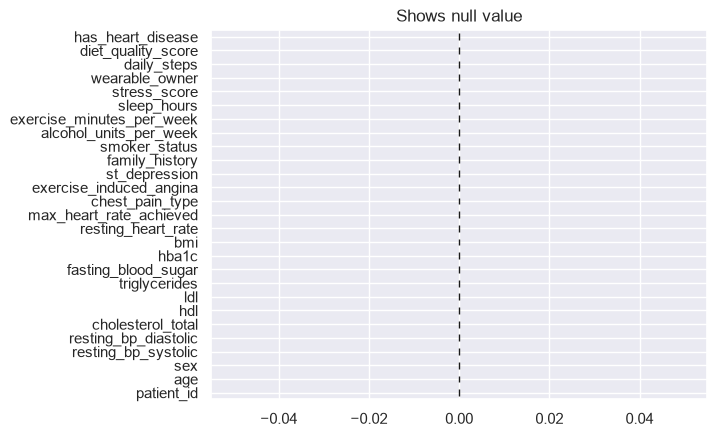

In [35]:
df.isnull().sum().plot(kind='barh',color='grey',edgecolor='k')
plt.title("Shows null value")
plt.show()

In [36]:
categotical_column=df.select_dtypes(include=object)
numerical_column=df.select_dtypes(exclude='object')
numerical_column


,patient_id,age,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,hba1c,...,st_depression,family_history,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
0,1,44,117,74,193,57,106,119,112,5.2,...,0.3,False,2.9,86,5.4,19.8,True,7731,62.9,0
1,2,57,139,94,185,69,110,35,114,5.9,...,2.1,False,3.0,132,4.3,45.8,True,2629,74.6,1
2,3,29,128,78,197,52,108,157,95,5.5,...,0.8,False,3.5,128,5.1,17.7,True,9290,65.7,0
3,4,72,132,86,197,59,104,143,92,4.8,...,2.1,False,2.7,18,6.8,63.6,True,7373,48.5,1
4,5,62,116,75,154,65,75,104,135,6.2,...,1.3,True,3.3,24,8.2,58.7,False,6331,47.3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8995,8996,36,108,63,178,68,82,158,96,5.3,...,1.1,False,13.0,306,8.6,51.1,False,7144,58.1,0
8996,8997,44,112,73,213,54,139,102,125,5.9,...,1.2,False,3.4,76,6.5,37.1,False,7395,68.9,0
8997,8998,57,144,93,198,66,113,79,102,5.7,...,1.9,False,3.9,194,6.2,46.3,False,7424,70.2,0
8998,8999,61,130,70,220,68,135,109,104,5.5,...,0.8,False,3.9,139,5.0,66.5,False,5716,43.8,1


In [37]:
stats=[]
for i in df.select_dtypes(include=('int64','float64')):
    numerical_stats=OrderedDict({
    "feacture":i,
    "count":df[i].count(),
    "mean":df[i].mean(),
    "median":df[i].median(),
    "std":df[i].std(),
    "variance":df[i].var(),
    "skew":df[i].skew(),
    "kurt":df[i].kurt(),
    "Q1":df[i].quantile(0.25),
    "Q3":df[i].quantile(0.75),
    "IQR":df[i].quantile(0.75)-df[i].quantile(0.25),
    "UW":(df[i].quantile(0.25)-1.5*(df[i].quantile(0.75)-df[i].quantile(0.25))),
    "LW":(df[i].quantile(0.75)+1.5*(df[i].quantile(0.75)-df[i].quantile(0.25)))

    })
    stats.append(numerical_stats)
    report=pd.DataFrame(stats)
report

,feacture,count,mean,median,std,variance,skew,kurt,Q1,Q3,IQR,UW,LW
0,patient_id,9000,4500.500000,4500.5,2598.220545,6.750750e+06,0.000000,-1.200000,2250.75,6750.25,4499.50,-4498.500,13499.500
1,age,9000,53.977333,54.0,13.008051,1.692094e+02,-0.021674,-0.205503,45.00,63.00,18.00,18.000,90.000
2,resting_bp_systolic,9000,127.849778,128.0,13.767233,1.895367e+02,0.067686,0.029089,119.00,137.00,18.00,92.000,164.000
3,resting_bp_diastolic,9000,80.788778,81.0,10.939943,1.196823e+02,0.008614,-0.079739,74.00,88.00,14.00,53.000,109.000
4,cholesterol_total,9000,188.753556,189.0,32.271644,1.041459e+03,0.003850,-0.028042,167.00,211.00,44.00,101.000,277.000
5,hdl,9000,55.215333,55.0,12.394400,1.536211e+02,0.020459,-0.031527,47.00,64.00,17.00,21.500,89.500
6,ldl,9000,103.275556,103.0,27.342198,7.475958e+02,0.044963,-0.098520,85.00,122.00,37.00,29.500,177.500
7,triglycerides,9000,152.045000,151.0,51.448384,2.646936e+03,0.125859,-0.024352,117.00,186.00,69.00,13.500,289.500
8,fasting_blood_sugar,9000,119.470444,119.0,22.778082,5.188410e+02,0.040870,-0.140283,104.00,135.00,31.00,57.500,181.500
9,hba1c,9000,5.791633,5.8,0.692645,4.797577e-01,0.029182,-0.076007,5.30,6.30,1.00,3.800,7.800


In [38]:
df.describe(include='object')

,sex,chest_pain_type,smoker_status
count,9000,9000,9000
unique,2,4,3
top,Male,Asymptomatic,Never
freq,4731,4265,4980


<Axes: >

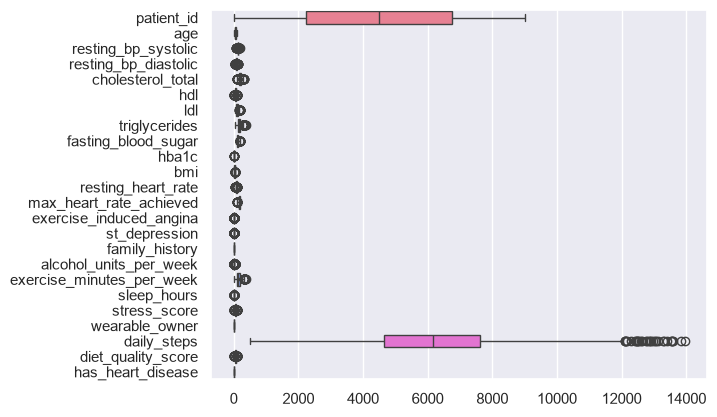

In [39]:
sns.boxplot(data=df,orient='h')


In [40]:
df.columns

Index(['patient_id', 'age', 'sex', 'resting_bp_systolic',
       'resting_bp_diastolic', 'cholesterol_total', 'hdl', 'ldl',
       'triglycerides', 'fasting_blood_sugar', 'hba1c', 'bmi',
       'resting_heart_rate', 'max_heart_rate_achieved', 'chest_pain_type',
       'exercise_induced_angina', 'st_depression', 'family_history',
       'smoker_status', 'alcohol_units_per_week', 'exercise_minutes_per_week',
       'sleep_hours', 'stress_score', 'wearable_owner', 'daily_steps',
       'diet_quality_score', 'has_heart_disease'],
      dtype='str')

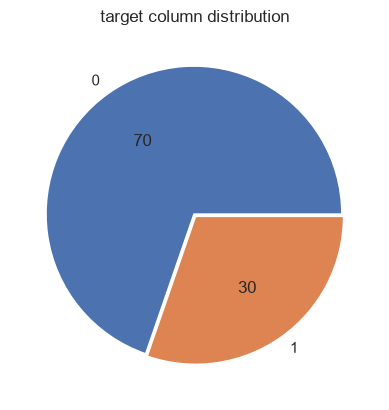

In [41]:
df['has_heart_disease'].value_counts().plot(kind='pie',autopct='%0.0f',explode=[0.01,0.01])
plt.title("target column distribution")
plt.show()

In [42]:
lc=LabelEncoder()
for i in df.select_dtypes(include=object):
    df[i]=lc.fit_transform(df[i])
df

,patient_id,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
0,1,44,1,117,74,193,57,106,119,112,...,False,2,2.9,86,5.4,19.8,True,7731,62.9,0
1,2,57,1,139,94,185,69,110,35,114,...,False,2,3.0,132,4.3,45.8,True,2629,74.6,1
2,3,29,1,128,78,197,52,108,157,95,...,False,0,3.5,128,5.1,17.7,True,9290,65.7,0
3,4,72,1,132,86,197,59,104,143,92,...,False,2,2.7,18,6.8,63.6,True,7373,48.5,1
4,5,62,0,116,75,154,65,75,104,135,...,True,1,3.3,24,8.2,58.7,False,6331,47.3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8995,8996,36,0,108,63,178,68,82,158,96,...,False,2,13.0,306,8.6,51.1,False,7144,58.1,0
8996,8997,44,0,112,73,213,54,139,102,125,...,False,1,3.4,76,6.5,37.1,False,7395,68.9,0
8997,8998,57,0,144,93,198,66,113,79,102,...,False,2,3.9,194,6.2,46.3,False,7424,70.2,0
8998,8999,61,0,130,70,220,68,135,109,104,...,False,1,3.9,139,5.0,66.5,False,5716,43.8,1


In [43]:
df['family_history'].map({'False':0,'True':1})

0      NaN
1      NaN
2      NaN
3      NaN
4      NaN
        ..
8995   NaN
8996   NaN
8997   NaN
8998   NaN
8999   NaN
Name: family_history, Length: 9000, dtype: float64

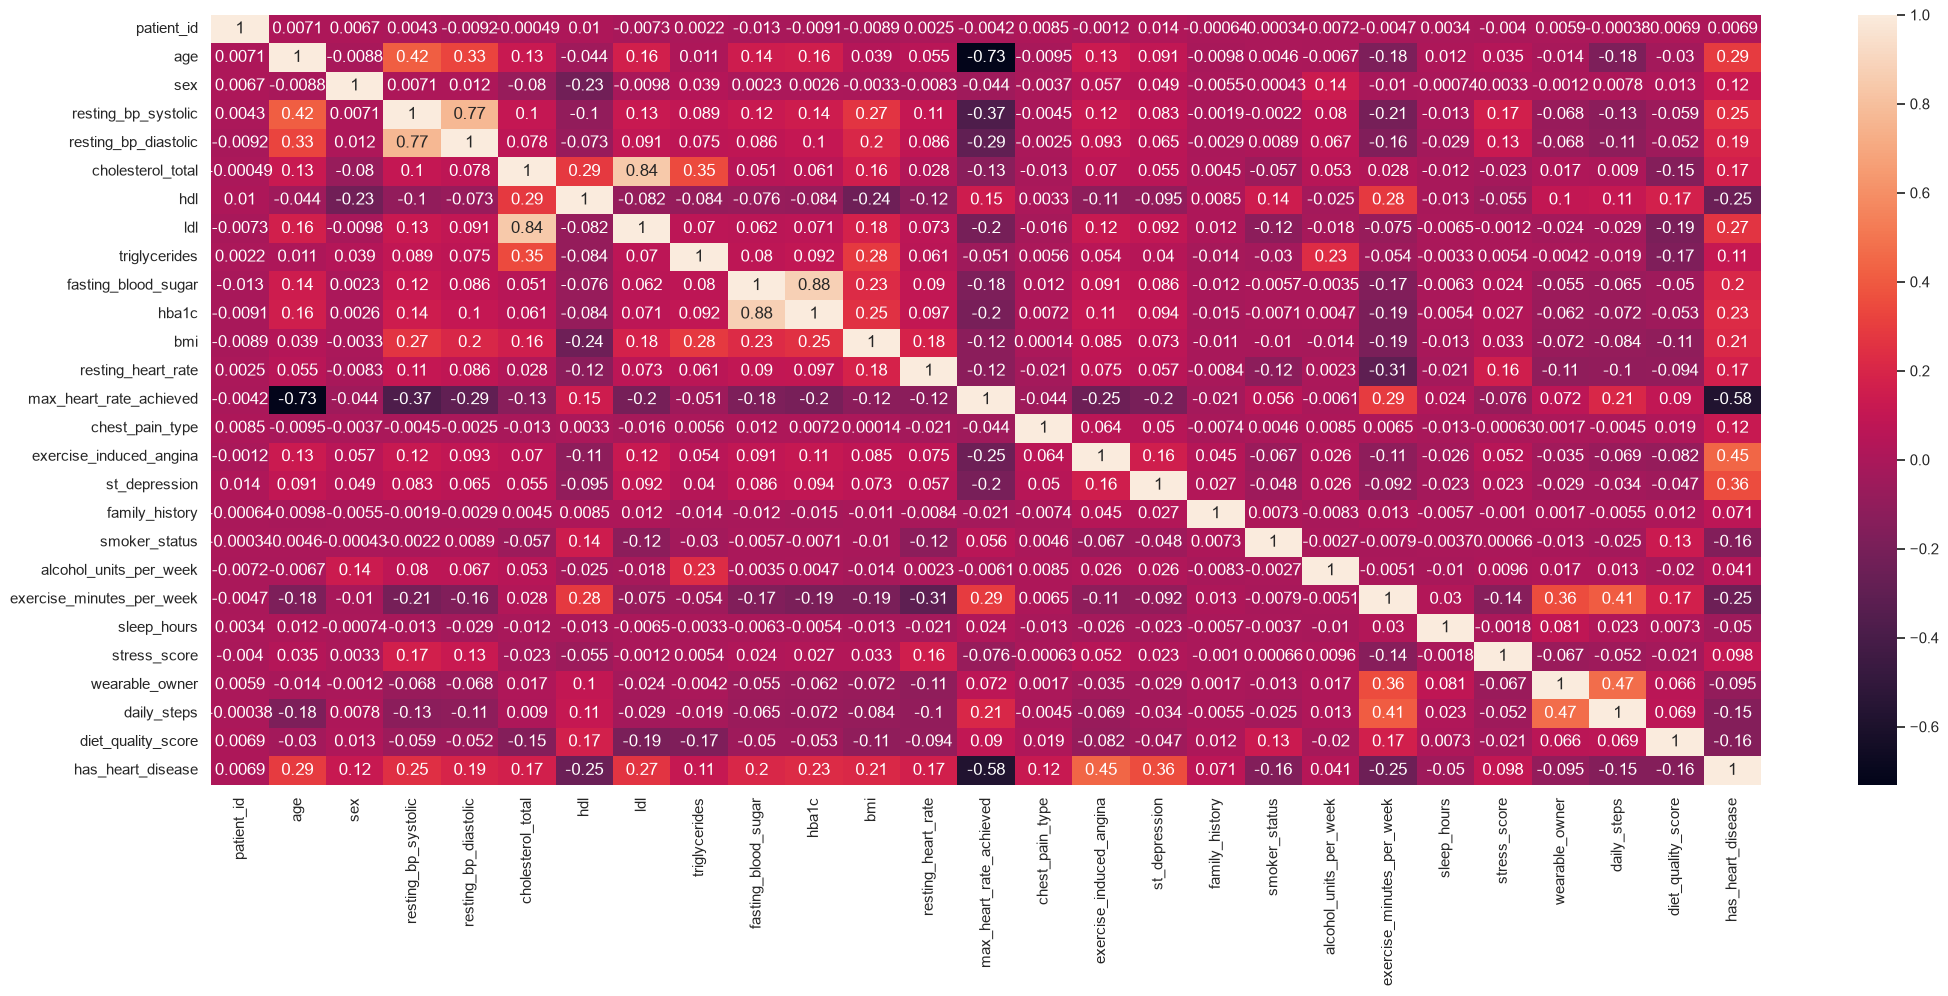

In [44]:
plt.figure(figsize=(25,10))
sns.heatmap(df.corr(),annot=True)
plt.show()

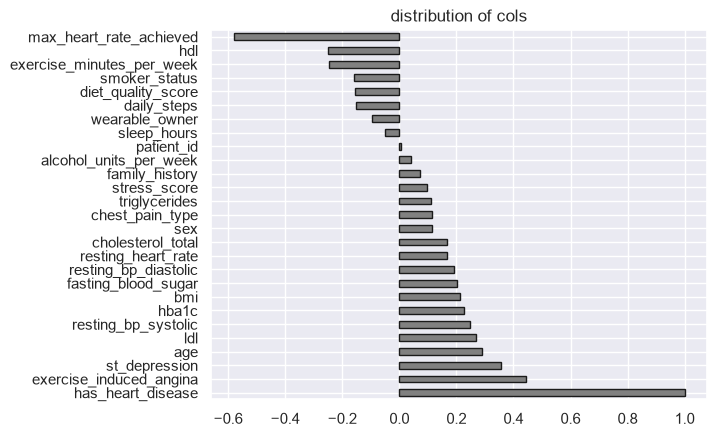

In [45]:
plt.title('distribution of cols')
df.corr()['has_heart_disease'].sort_values(ascending=False).plot(kind='barh',color='grey',edgecolor='k')
plt.show()

In [46]:
df.columns

Index(['patient_id', 'age', 'sex', 'resting_bp_systolic',
       'resting_bp_diastolic', 'cholesterol_total', 'hdl', 'ldl',
       'triglycerides', 'fasting_blood_sugar', 'hba1c', 'bmi',
       'resting_heart_rate', 'max_heart_rate_achieved', 'chest_pain_type',
       'exercise_induced_angina', 'st_depression', 'family_history',
       'smoker_status', 'alcohol_units_per_week', 'exercise_minutes_per_week',
       'sleep_hours', 'stress_score', 'wearable_owner', 'daily_steps',
       'diet_quality_score', 'has_heart_disease'],
      dtype='str')

In [47]:
df.drop(columns=['patient_id',],inplace=True)


In [48]:
df.columns

Index(['age', 'sex', 'resting_bp_systolic', 'resting_bp_diastolic',
       'cholesterol_total', 'hdl', 'ldl', 'triglycerides',
       'fasting_blood_sugar', 'hba1c', 'bmi', 'resting_heart_rate',
       'max_heart_rate_achieved', 'chest_pain_type', 'exercise_induced_angina',
       'st_depression', 'family_history', 'smoker_status',
       'alcohol_units_per_week', 'exercise_minutes_per_week', 'sleep_hours',
       'stress_score', 'wearable_owner', 'daily_steps', 'diet_quality_score',
       'has_heart_disease'],
      dtype='str')

In [49]:
X=df.drop(columns=['has_heart_disease'])
y=df['has_heart_disease']


In [50]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=1)

In [51]:
from imblearn.over_sampling import SMOTE
sc=SMOTE()

X_train,y_train=sc.fit_resample(X_train,y_train)
y_train.value_counts()

has_heart_disease
1    4376
0    4376
Name: count, dtype: int64

<Axes: >

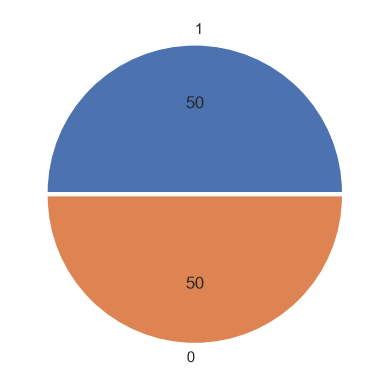

In [52]:
y_train.value_counts().plot(kind='pie',autopct='%0.0f',explode=[0.01,0.01])

In [53]:
# sc=MinMaxScaler()
# X_train=sc.fit_transform(X_train)
# X_test=sc.transform(X_test)

In [54]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

models=({
    "linear regressor":LinearRegression(),
    "ridge":Ridge(),
    "lasso":Lasso(),
    "huber":HuberRegressor(),
    "ransac":RANSACRegressor(),
    "randomforest":RandomForestRegressor(),
    "decisiontree":DecisionTreeRegressor(),
    "extratree":ExtraTreesRegressor(),
    "knn":KNeighborsRegressor(),
    "svm":SVR(),

    
})
for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    r2_score_test=model.score(X_test,y_test)
    print(f"testing {name}r2_score is={r2_score_test}")

testing linear regressorr2_score is=0.5338978332759128
testing ridger2_score is=0.5338930848396247
testing lassor2_score is=0.28090732360750836
testing huberr2_score is=0.2700718099933507
testing ransacr2_score is=0.19626967290240505
testing randomforestr2_score is=0.5674727941017179
testing decisiontreer2_score is=0.14566553600067234
testing extratreer2_score is=0.5731941762933018
testing knnr2_score is=-0.08057357392645281
testing svmr2_score is=0.03967964022450354


0.8181481481481482
              precision    recall  f1-score   support

           0       0.88      0.86      0.87      1897
           1       0.68      0.72      0.70       803

    accuracy                           0.82      2700
   macro avg       0.78      0.79      0.79      2700
weighted avg       0.82      0.82      0.82      2700



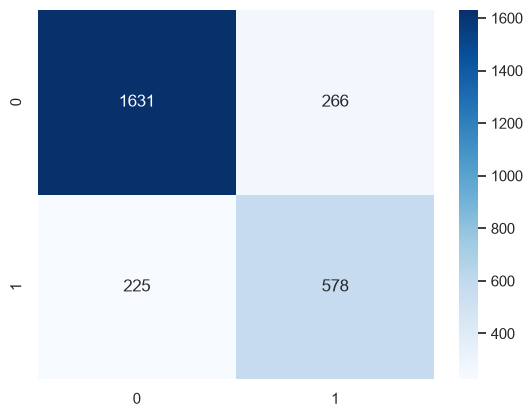

0.8792592592592593
              precision    recall  f1-score   support

           0       0.91      0.92      0.91      1897
           1       0.80      0.79      0.80       803

    accuracy                           0.88      2700
   macro avg       0.86      0.85      0.86      2700
weighted avg       0.88      0.88      0.88      2700



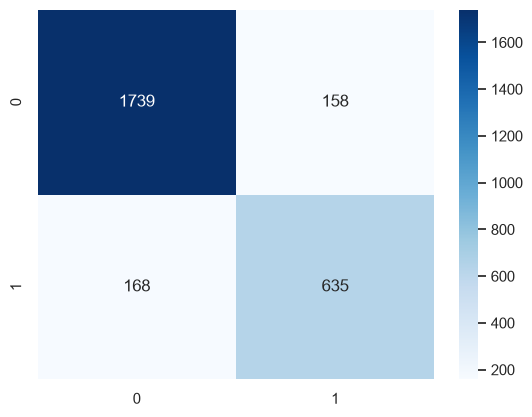

0.8751851851851852
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      1897
           1       0.80      0.77      0.79       803

    accuracy                           0.88      2700
   macro avg       0.85      0.84      0.85      2700
weighted avg       0.87      0.88      0.87      2700



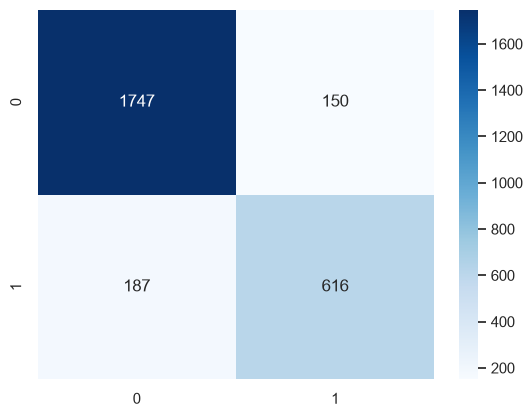

0.6751851851851852
              precision    recall  f1-score   support

           0       0.83      0.67      0.74      1897
           1       0.47      0.69      0.56       803

    accuracy                           0.68      2700
   macro avg       0.65      0.68      0.65      2700
weighted avg       0.73      0.68      0.69      2700



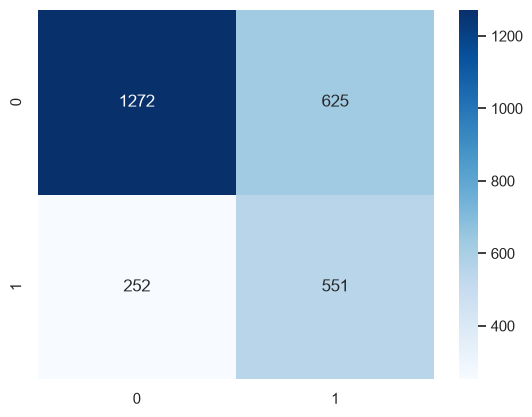

In [55]:
models =({
    "dt":DecisionTreeClassifier(),
    "rf":RandomForestClassifier(),
    "et":ExtraTreesClassifier(),
    "knn":KNeighborsClassifier()
})
for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    accuracy=accuracy_score(y_test,y_pred)
    cr=classification_report(y_test,y_pred)
    print(accuracy)
    print(cr)
    cf=confusion_matrix(y_test,y_pred)
    sns.heatmap(cf,annot=True,fmt='g',cmap='Blues') # fmt g convert numbers in integrs
    plt.show()

In [56]:
model_rf=RandomForestClassifier().fit(X_train,y_train)

y_pred_rf=model_rf.predict(X_test)

accuracy=accuracy_score(y_test,y_pred_rf)
report=classification_report(y_test,y_pred_rf)
print(accuracy)
print(report)

0.882962962962963
              precision    recall  f1-score   support

           0       0.91      0.92      0.92      1897
           1       0.81      0.79      0.80       803

    accuracy                           0.88      2700
   macro avg       0.86      0.86      0.86      2700
weighted avg       0.88      0.88      0.88      2700



In [57]:
model_rf=DecisionTreeClassifier().fit(X_train,y_train)

y_pred_dt=model_rf.predict(X_test)

accuracy=accuracy_score(y_test,y_pred_dt)
report=classification_report(y_test,y_pred_dt)
print(accuracy)
print(report)

0.8111111111111111
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      1897
           1       0.67      0.71      0.69       803

    accuracy                           0.81      2700
   macro avg       0.77      0.78      0.78      2700
weighted avg       0.81      0.81      0.81      2700



In [58]:
model_rf=ExtraTreesClassifier().fit(X_train,y_train)

y_pred_et=model_rf.predict(X_test)

accuracy=accuracy_score(y_test,y_pred_et)
report=classification_report(y_test,y_pred_et)
print(accuracy)
print(report)

0.8759259259259259
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      1897
           1       0.81      0.77      0.79       803

    accuracy                           0.88      2700
   macro avg       0.85      0.84      0.85      2700
weighted avg       0.87      0.88      0.88      2700



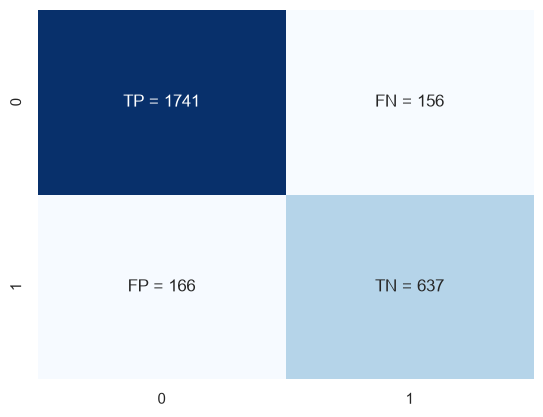

In [59]:
cf=confusion_matrix(y_test,y_pred_rf)
cf=np.array([[1741,156],[166,637]])
labels = np.array([
    ["TP = 1741", "FN = 156"],
    ["FP = 166",  "TN = 637"]
])
sns.heatmap(cf,annot=labels,fmt='',cmap='Blues',cbar=False)
plt.show()

In [67]:
from flaml import AutoML

# Initialize an AutoML instance
automl = AutoML()
# Specify automl goal and constraint
automl_settings = {
    "time_budget": 10,  # in seconds
    "metric": "accuracy",
    "task": "classification",
    "log_file_name": "model.log",
}
# Train with labeled input data
automl.fit(X_train=X_train, y_train=y_train, **automl_settings)
# Predict
print(automl.predict_proba(X_train))
# Print the best model
print(automl.model.estimator)

[flaml.automl.logger: 07-31 14:46:33] {2375} INFO - task = classification
[flaml.automl.logger: 07-31 14:46:33] {2386} INFO - Evaluation method: holdout
[flaml.automl.logger: 07-31 14:46:33] {2489} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 07-31 14:46:33] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'lrl1']
[flaml.automl.logger: 07-31 14:46:33] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 07-31 14:46:33] {3046} INFO - Estimated sufficient time budget=283s. Estimated necessary time budget=7s.
[flaml.automl.logger: 07-31 14:46:33] {3097} INFO -  at 0.1s,	estimator lgbm's best error=1.6781e-01,	best estimator lgbm's best error=1.6781e-01
[flaml.automl.logger: 07-31 14:46:33] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 07-31 14:46:33] {3097} INFO -  at 0.1s,	estimator lgbm's best error=1.6781e-01,	best estimator lgbm's best error=1.6781e-01
[flaml.a

In [66]:
y_pred = automl.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.91      0.92      1897
           1       0.79      0.82      0.81       803

    accuracy                           0.88      2700
   macro avg       0.86      0.87      0.86      2700
weighted avg       0.89      0.88      0.88      2700

